In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

data = {
    'Study_Hours': [1,2,3,4,5,6,7,8,9,10],
    'Attendance': [50,55,60,65,70,75,80,85,90,95],
    'Previous_Score': [40,45,50,55,60,65,70,75,80,85],
    'Result': [0,0,0,0,1,1,1,1,1,1]  # 0=Fail, 1=Pass
}

df = pd.DataFrame(data)
print(df)

   Study_Hours  Attendance  Previous_Score  Result
0            1          50              40       0
1            2          55              45       0
2            3          60              50       0
3            4          65              55       0
4            5          70              60       1
5            6          75              65       1
6            7          80              70       1
7            8          85              75       1
8            9          90              80       1
9           10          95              85       1


In [3]:
X = df.drop('Result', axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [5]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [6]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


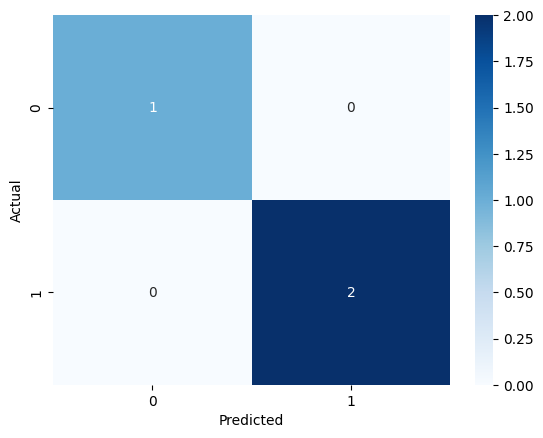

In [7]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

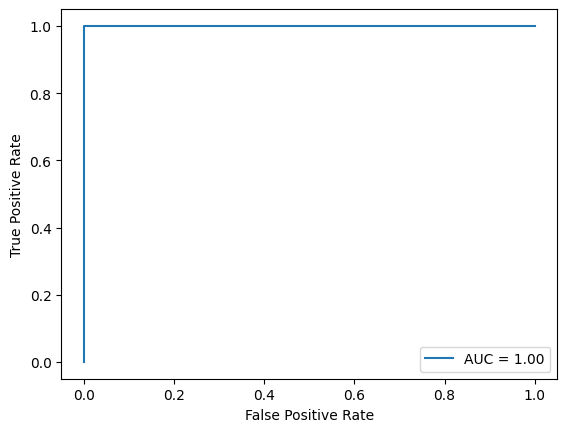

In [8]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

“Built a supervised machine learning predictive model using Decision Tree and Random Forest algorithms. Performed data preprocessing, trained and tested models, and evaluated performance using accuracy, confusion matrix, and ROC curve.”